# Projeto Prático: Análise Exploratória de Dados
**Tema:** Perfil Estatístico dos Jogadores da Seleção Brasileira (Ciclo Copa 2026)
**Grupo 9**

---

## 1. Entendimento do Problema e Contexto
O objetivo deste projeto é analisar estatisticamente o desempenho dos jogadores cotados para representar o Brasil na Copa do Mundo de 2026. Utilizando medidas de centralização, dispersão e correlação, buscaremos entender o padrão numérico (jogos, gols, assistências) que define um jogador de nível de Seleção.

---

## 2. Importação de Bibliotecas e Configuração

In [1]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualização gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo padrão dos gráficos para ficarem mais bonitos
sns.set_theme(style="whitegrid")

# Define o tamanho padrão dos gráficos
plt.rcParams['figure.figsize'] = (10, 6) 

---
## 3. Leitura e Limpeza dos Dados
Nesta etapa, faremos o carregamento do arquivo CSV contendo os dados primários coletados pelo grupo e a verificação inicial das colunas.

In [2]:
# Lendo o arquivo Excel DIRETAMENTE da pasta 'data'
dfs = pd.read_excel("Dataset.xlsx", sheet_name=None)

# Separando as abas da planilha em variáveis diferentes
df_todos = dfs['Todos']
df_zagueiro = dfs['Zagueiro']
df_meio = dfs['Meio-Campo']
df_atacantes = dfs['Atacantes']
df_goleiros = dfs['Goleiros']

# 1.1- Identificação e tratamento de colunas vazias
for nome in dfs:
    dfs[nome] = dfs[nome].loc[:, ~dfs[nome].columns.str.contains('^Unnamed')]

# 1.2- Identificação de dados duplicados
for nome, df in dfs.items():
    print(f"{nome}: {df.duplicated().sum()} duplicados encontrados")

# Exibindo as 5 primeiras linhas da aba 'Todos' para confirmar o sucesso!
display(df_todos.head())

Todos: 0 duplicados encontrados
Zagueiro: 0 duplicados encontrados
Meio-Campo: 0 duplicados encontrados
Atacantes: 0 duplicados encontrados
Goleiros: 0 duplicados encontrados


,Jogador,Posição,Idade,Perna boa,Clube
0,Endrick,Atacante,19,Canhoto,Lyon
1,G. Martinelli,Atacante,24,Destro,Arsenal
2,Igor Thiago,Atacante,24,Destro,Brentford
3,João Pedro,Atacante,24,Destro,Chelsea
4,Luiz henrique,Atacante,25,Canhoto,Zenit


## 4. Análise Exploratória Inicial

--- Resumo Estatístico ---


,Idade
Quantidade,53.000000
Média idades,27.018868
Desvio Padrão,4.016747
Mínimo (idade),18.000000
1º Quartil (25%),24.000000
Mediana (50%),27.000000
3º Quartil (75%),30.000000
Máximo (idade),35.000000


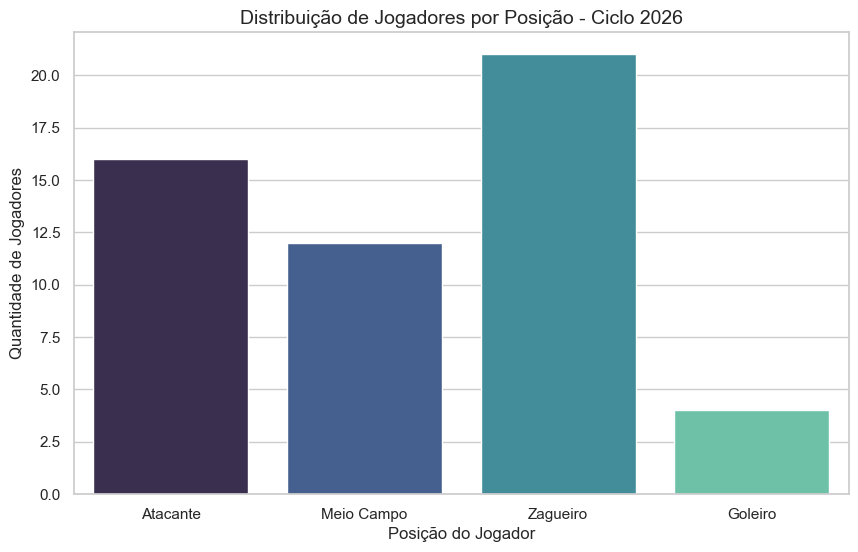

In [8]:
# 1. LIMPANDO OS DADOS: Removendo espaços invisíveis do começo e do final do texto
df_todos['Posição'] = df_todos['Posição'].str.strip()

# 2. Resumo Estatístico 
print("--- Resumo Estatístico ---")
resumo = df_todos.describe()

# Renomeia as linhas (índice) da tabela
resumo = resumo.rename(index={
    'count': 'Quantidade',
    'mean': 'Média idades',
    'std': 'Desvio Padrão',
    'min': 'Mínimo (idade)',
    '25%': '1º Quartil (25%)',
    '50%': 'Mediana (50%)',
    '75%': '3º Quartil (75%)',
    'max': 'Máximo (idade)'
})

# Exibe a tabela traduzida
display(resumo)

# 3. Criando o gráfico corrigido
sns.countplot(data=df_todos, x='Posição', hue='Posição', palette='mako')

plt.title('Distribuição de Jogadores por Posição - Ciclo 2026', fontsize=14)
plt.xlabel('Posição do Jogador')
plt.ylabel('Quantidade de Jogadores')

plt.show()

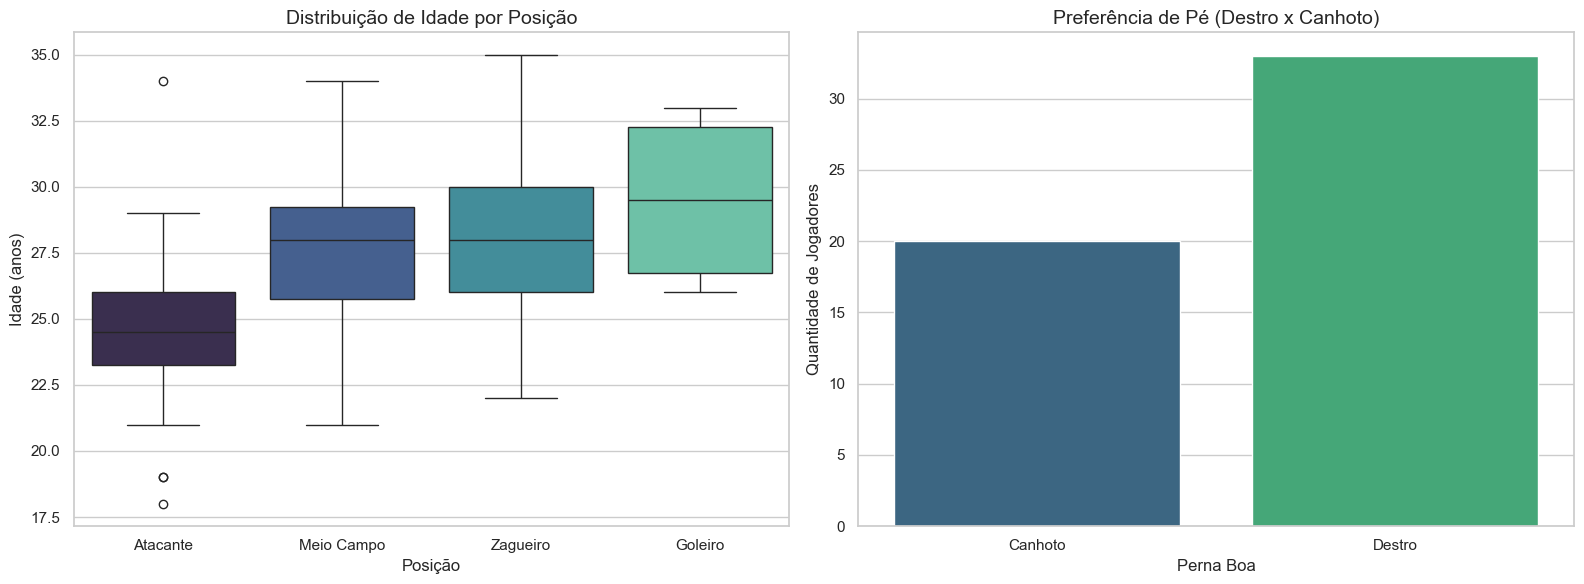

In [9]:
# Criando uma "tela" com 2 espaços lado a lado para os gráficos
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Boxplot de Idade por Posição (mostra a variação e a média)
sns.boxplot(data=df_todos, x='Posição', y='Idade', hue='Posição', palette='mako', ax=ax[0])
ax[0].set_title('Distribuição de Idade por Posição', fontsize=14)
ax[0].set_xlabel('Posição')
ax[0].set_ylabel('Idade (anos)')

# Gráfico 2: Quantidade de jogadores por Perna Boa
sns.countplot(data=df_todos, x='Perna boa', hue='Perna boa', palette='viridis', ax=ax[1])
ax[1].set_title('Preferência de Pé (Destro x Canhoto)', fontsize=14)
ax[1].set_xlabel('Perna Boa')
ax[1].set_ylabel('Quantidade de Jogadores')

# Ajusta o espaçamento para não ficar nada sobreposto e mostra na tela
plt.tight_layout()
plt.show()

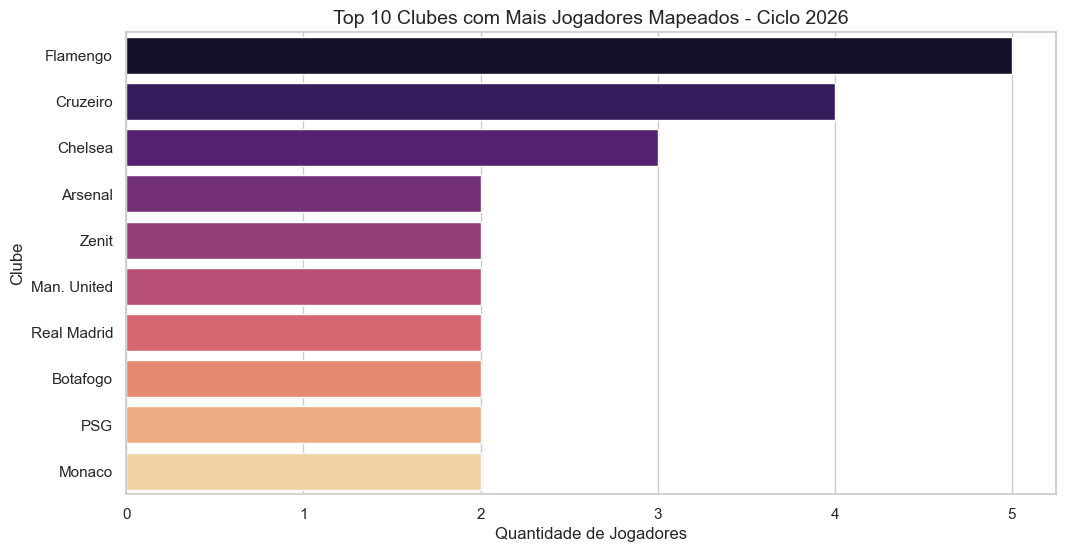

In [11]:
# Criando a figura com um tamanho legal
plt.figure(figsize=(12, 6))

# Contando os jogadores por clube e pegando apenas os 10 primeiros
top_clubes = df_todos['Clube'].value_counts().head(10)

# Criando um gráfico de barras horizontais
sns.barplot(x=top_clubes.values, y=top_clubes.index, hue=top_clubes.index, palette='magma', legend=False)

# Adicionando os títulos
plt.title('Top 10 Clubes com Mais Jogadores Mapeados - Ciclo 2026', fontsize=14)
plt.xlabel('Quantidade de Jogadores')
plt.ylabel('Clube')

# Exibindo o gráfico
plt.show()

In [13]:
# === REQUISITO 1: Completando as Estatísticas ===
print("--- Medidas Adicionais (Idade) ---")

# 1. Moda (Medida de Centralização: O valor que mais aparece)
moda_idade = df_todos['Idade'].mode()[0]
print(f"Moda: {moda_idade} anos")

# 2. Variância (Medida de Dispersão: O quão distante os valores estão da média)
variancia_idade = df_todos['Idade'].var()
print(f"Variância: {variancia_idade:.2f}")

# 3. Amplitude (Medida de Dispersão: Diferença entre o máximo e o mínimo)
amplitude_idade = df_todos['Idade'].max() - df_todos['Idade'].min()
print(f"Amplitude: {amplitude_idade} anos")

--- Medidas Adicionais (Idade) ---
Moda: 28 anos
Variância: 16.13
Amplitude: 17 anos


## 5. Análise de Desempenho e Correlação

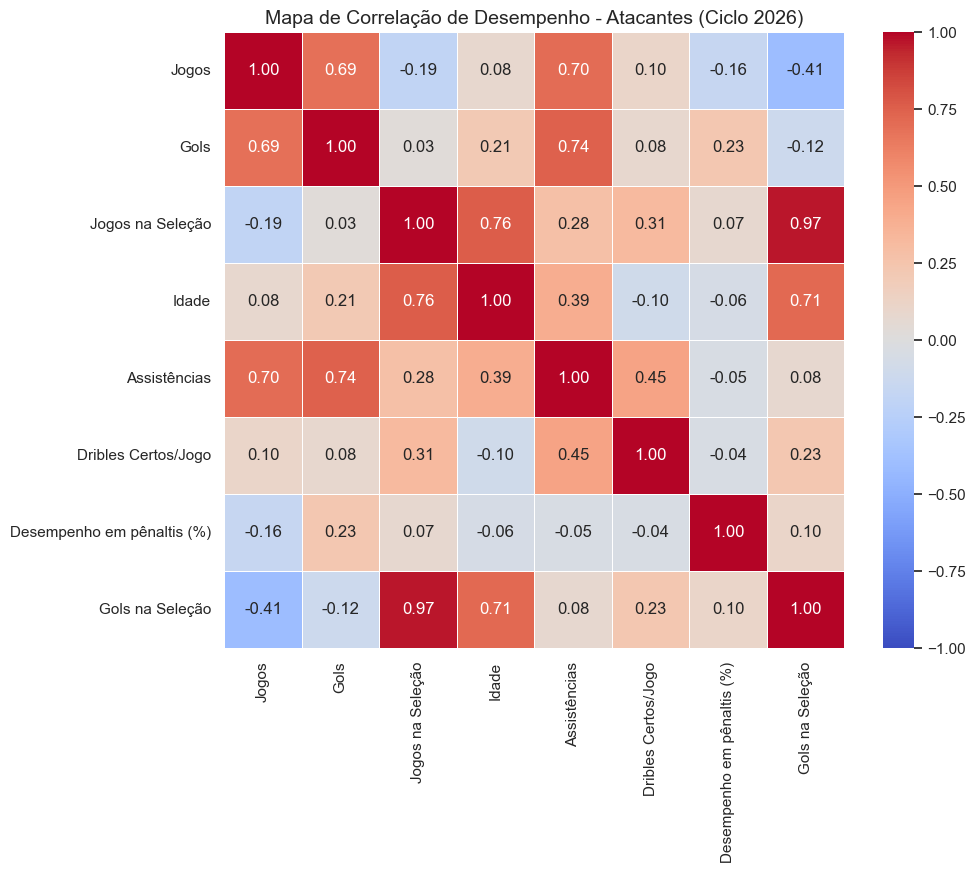

In [16]:
# 1. Definir o tamanho do gráfico
plt.figure(figsize=(10, 8))

# 2. O SEGREDO: Usar a variável df_atacantes em vez da df_todos
# Isto vai buscar os Gols, Jogos, Assistências e Idade dos atacantes
dados_numericos_atacantes = df_atacantes.select_dtypes(include='number')

# 3. Calcular a matriz de correlação matemática
correlacao = dados_numericos_atacantes.corr()

# 4. Desenhar o Mapa de Calor (Heatmap)
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

# 5. Adicionar o título
plt.title('Mapa de Correlação de Desempenho - Atacantes (Ciclo 2026)', fontsize=14)

# 6. Exibir o gráfico
plt.show()